# 🍷 Wine Quality Classification (Random Forest)

**Tujuan:** Memprediksi kualitas anggur (`quality`, skala 0–10) berdasarkan fitur-fitur kimiawi.

**Metode:** Random Forest Classifier

**Dataset:**
- `data_training.csv` — 857 sampel dengan label `quality`
- `data_testing.csv` — 286 sampel tanpa label (yang akan diprediksi)

---

## 1. Import Library

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_val_predict

import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset

In [30]:
# Sesuaikan path jika menggunakan Kaggle
train = pd.read_csv("/kaggle/input/datasets/aaronchristiandaniel/quality/data_training.csv")
test  = pd.read_csv("/kaggle/input/datasets/aaronchristiandaniel/quality/data_testing.csv")

print(f'Training set : {train.shape[0]} baris, {train.shape[1]} kolom')
print(f'Testing set  : {test.shape[0]} baris, {test.shape[1]} kolom')

Training set : 857 baris, 13 kolom
Testing set  : 286 baris, 12 kolom


## 3. Eksplorasi Data (EDA)

In [31]:
train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


In [32]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


In [33]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,857.0,8.261960,1.701992,4.60000,7.10000,7.90000,9.1000,15.6000
volatile acidity,857.0,0.529393,0.179162,0.12000,0.39500,0.52000,0.6400,1.5800
citric acid,857.0,0.267351,0.195144,0.00000,0.09000,0.25000,0.4200,1.0000
residual sugar,857.0,2.506184,1.293512,0.90000,1.90000,2.20000,2.6000,15.5000
chlorides,857.0,0.086830,0.048721,0.01200,0.07000,0.07900,0.0900,0.6110
free sulfur dioxide,857.0,15.782964,10.300402,1.00000,7.00000,14.00000,21.0000,68.0000
total sulfur dioxide,857.0,45.978413,31.692113,6.00000,21.00000,38.00000,63.0000,278.0000
density,857.0,0.996692,0.001901,0.99007,0.99552,0.99668,0.9978,1.0032
pH,857.0,3.313092,0.152079,2.74000,3.21000,3.31000,3.4000,4.0100
sulphates,857.0,0.656709,0.167364,0.39000,0.55000,0.62000,0.7300,2.0000


In [34]:
# Cek missing values
print('Missing values (training):')
print(train.isnull().sum())
print()
print('Missing values (testing):')
print(test.isnull().sum())

Missing values (training):
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Missing values (testing):
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64


**Interpretasi:** Tidak ada missing value di kedua dataset. Data bersih dan siap diproses.

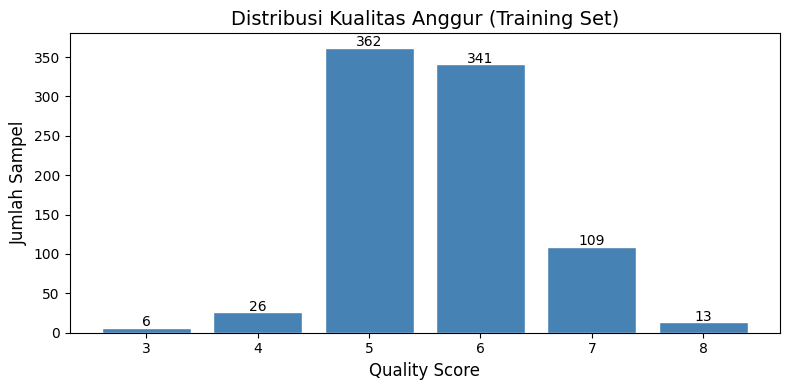

quality
3      6
4     26
5    362
6    341
7    109
8     13
Name: count, dtype: int64


In [35]:
# Distribusi variabel target
fig, ax = plt.subplots(figsize=(8, 4))
quality_counts = train['quality'].value_counts().sort_index()
bars = ax.bar(quality_counts.index, quality_counts.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Quality Score', fontsize=12)
ax.set_ylabel('Jumlah Sampel', fontsize=12)
ax.set_title('Distribusi Kualitas Anggur (Training Set)', fontsize=14)
for bar, val in zip(bars, quality_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(val),
            ha='center', fontsize=10)
plt.tight_layout()
plt.show()
print(quality_counts)

**Interpretasi:** Dataset tidak seimbang (*imbalanced*). Kelas 5 dan 6 mendominasi (~82% dari data), sementara kelas 3 dan 8 sangat sedikit. Model cenderung kesulitan memprediksi kelas minoritas.

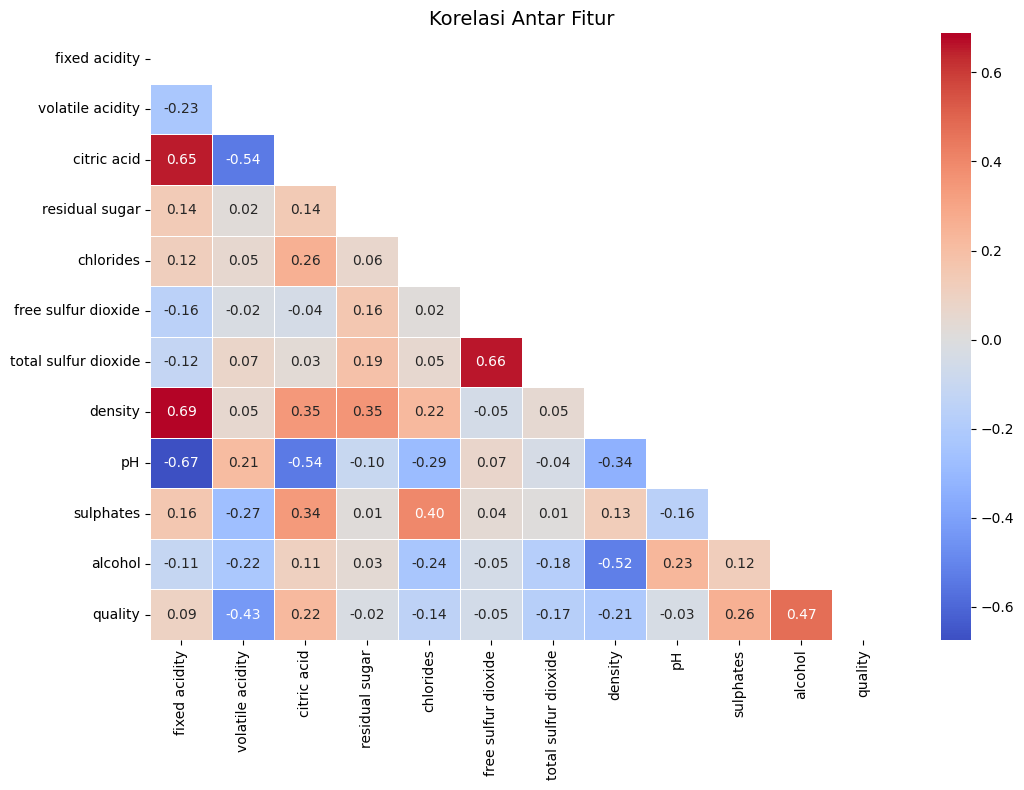

In [36]:
# Heatmap korelasi
fig, ax = plt.subplots(figsize=(11, 8))
features_for_corr = [c for c in train.columns if c != 'Id']
corr = train[features_for_corr].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Korelasi Antar Fitur', fontsize=14)
plt.tight_layout()
plt.show()

**Interpretasi:**
- `alcohol` memiliki korelasi positif tertinggi dengan `quality` (+0.47)
- `volatile acidity` berkorelasi negatif dengan `quality` (-0.39)
- `density` dan `fixed acidity` berkorelasi kuat (+0.67), namun keduanya tetap dipertahankan karena Random Forest tahan terhadap multikolinearitas

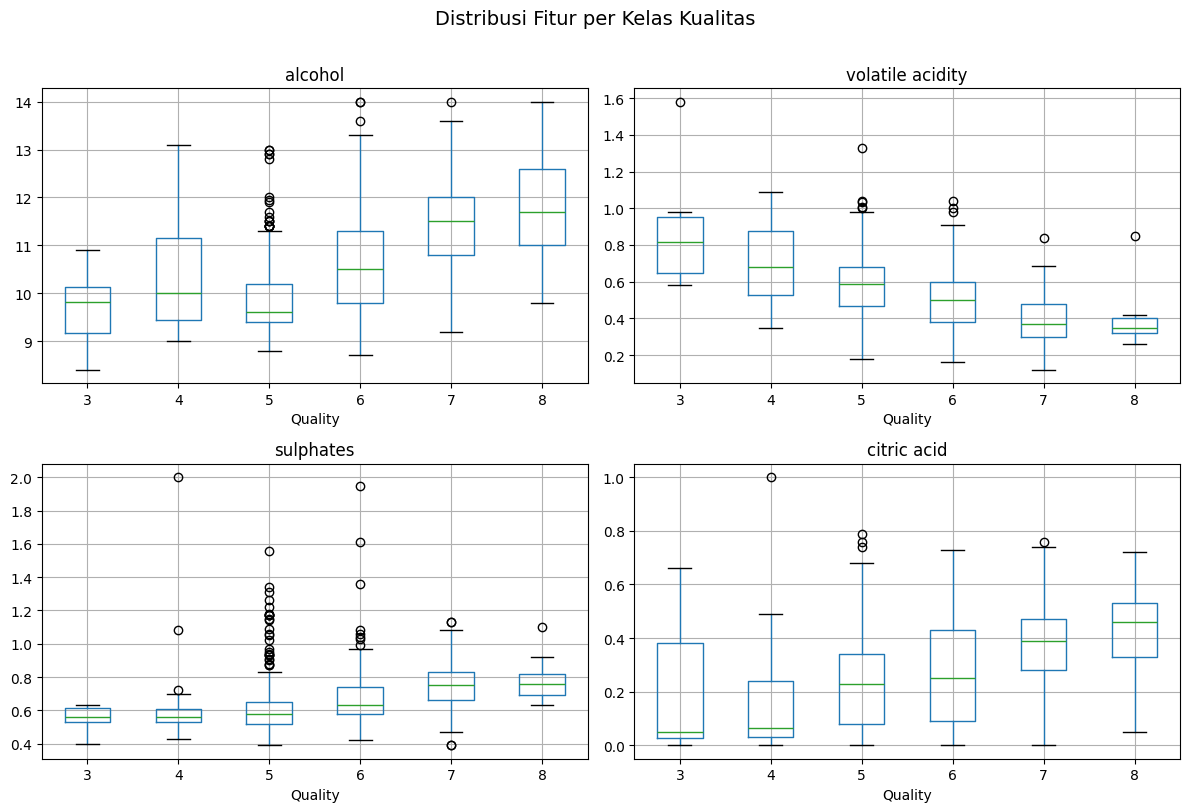

In [37]:
# Boxplot fitur vs kualitas
top_features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, feat in enumerate(top_features):
    train.boxplot(column=feat, by='quality', ax=axes[i])
    axes[i].set_title(feat, fontsize=12)
    axes[i].set_xlabel('Quality')
plt.suptitle('Distribusi Fitur per Kelas Kualitas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. Persiapan Data

In [38]:
# Pisahkan fitur dan target
FEATURES = [c for c in train.columns if c not in ['quality', 'Id']]

X_train = train[FEATURES]
y_train = train['quality']
X_test  = test[FEATURES]
test_ids = test['Id']

print('Fitur yang digunakan:', FEATURES)
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape : {X_test.shape}')

Fitur yang digunakan: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
X_train shape: (857, 11)
X_test shape : (286, 11)


## 5. Pemodelan — Random Forest Classifier

In [39]:
# Inisialisasi dan latih model
rf_model = RandomForestClassifier(
    n_estimators=300,       # jumlah pohon
    max_depth=None,         # pohon tumbuh penuh
    min_samples_split=2,    # minimum sampel untuk split node
    min_samples_leaf=1,     # minimum sampel di leaf
    max_features='sqrt',    # jumlah fitur per split = sqrt(n_features)
    random_state=42,
    n_jobs=-1               # gunakan semua CPU core
)

rf_model.fit(X_train, y_train)
print('Model dilatih')

Model dilatih


## 6. Evaluasi Model

In [40]:
# Cross-Validation 5-fold Stratified
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=skf, scoring='accuracy')

print('Cross-Validation (5-Fold Stratified):')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score:.4f}')
print(f'  Mean   : {cv_scores.mean():.4f}')
print(f'  Std    : {cv_scores.std():.4f}')

Cross-Validation (5-Fold Stratified):
  Fold 1: 0.5698
  Fold 2: 0.6570
  Fold 3: 0.6316
  Fold 4: 0.6725
  Fold 5: 0.6842
  Mean   : 0.6430
  Std    : 0.0406


In [41]:
# Evaluasi pada training set (in-sample)
y_train_pred = rf_model.predict(X_train)
print('Classification Report (Training Set):')
print(classification_report(y_train, y_train_pred))

Classification Report (Training Set):
              precision    recall  f1-score   support

           3       1.00      1.00      1.00         6
           4       1.00      1.00      1.00        26
           5       1.00      1.00      1.00       362
           6       1.00      1.00      1.00       341
           7       1.00      1.00      1.00       109
           8       1.00      1.00      1.00        13

    accuracy                           1.00       857
   macro avg       1.00      1.00      1.00       857
weighted avg       1.00      1.00      1.00       857



**Interpretasi:** Cross-validation 5-fold digunakan untuk mendapatkan estimasi performa yang lebih reliable. StratifiedKFold memastikan proporsi tiap kelas terjaga di setiap fold — penting karena dataset kita imbalanced.

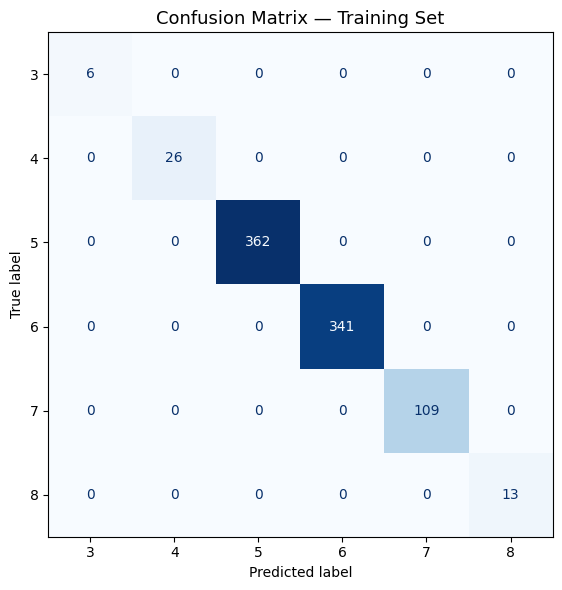

In [42]:
# Confusion Matrix training set
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_train, y_train_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=sorted(y_train.unique()))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Training Set', fontsize=13)
plt.tight_layout()
plt.show()

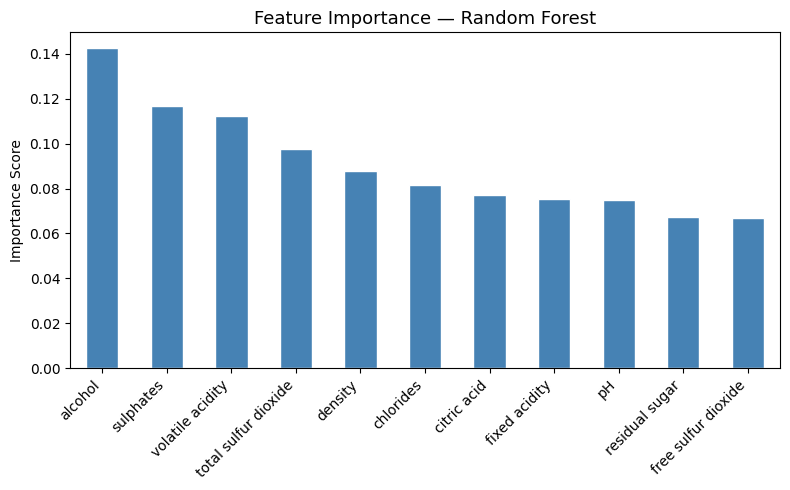


Feature Importance:
alcohol                 0.142431
sulphates               0.116549
volatile acidity        0.112228
total sulfur dioxide    0.097791
density                 0.087950
chlorides               0.081558
citric acid             0.077177
fixed acidity           0.075296
pH                      0.074836
residual sugar          0.067229
free sulfur dioxide     0.066955


In [43]:
# Feature Importance
fi = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
fi.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Feature Importance — Random Forest', fontsize=13)
ax.set_ylabel('Importance Score')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nFeature Importance:')
print(fi.to_string())

**Interpretasi Feature Importance:**
- **`alcohol`** adalah fitur terpenting — kandungan alkohol yang lebih tinggi umumnya berkaitan dengan kualitas yang lebih baik
- **`sulphates`** dan **`volatile acidity`** juga sangat berpengaruh. Volatile acidity yang tinggi mengindikasikan kualitas rendah (rasa asam cuka)
- **`total sulfur dioxide`** dan **`density`** memberikan kontribusi menengah
- Semua 11 fitur berkontribusi, artinya tidak ada fitur yang sepenuhnya tidak relevan

## 7. Prediksi Data Testing

Distribusi Hasil Prediksi:
5    132
6    125
7     29
Name: count, dtype: int64


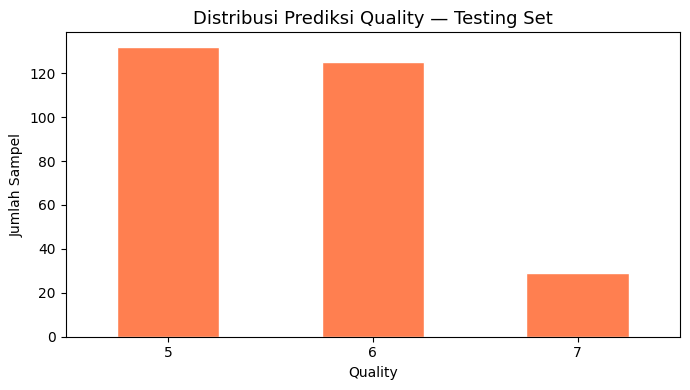

In [44]:
# Prediksi
y_pred = rf_model.predict(X_test)

# Distribusi prediksi
pred_dist = pd.Series(y_pred).value_counts().sort_index()
print('Distribusi Hasil Prediksi:')
print(pred_dist)

fig, ax = plt.subplots(figsize=(7, 4))
pred_dist.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.set_title('Distribusi Prediksi Quality — Testing Set', fontsize=13)
ax.set_xlabel('Quality')
ax.set_ylabel('Jumlah Sampel')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Simpan Hasil Prediksi

In [45]:
# Buat DataFrame hasil prediksi
submission = pd.DataFrame({
    'Id': test_ids,
    'quality': y_pred
})

print('Preview submission:')
print(submission.head(10))
print(f'\nTotal prediksi: {len(submission)} baris')
print('Kolom:', submission.columns.tolist())

Preview submission:
     Id  quality
0   222        5
1  1514        6
2   417        5
3   754        5
4   516        5
5  1120        6
6   180        5
7    82        5
8   632        6
9   592        5

Total prediksi: 286 baris
Kolom: ['Id', 'quality']


Classification Report (Cross-Validation 5-Fold):
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00        26
           5       0.68      0.75      0.71       362
           6       0.61      0.67      0.63       341
           7       0.62      0.46      0.53       109
           8       1.00      0.15      0.27        13

    accuracy                           0.64       857
   macro avg       0.48      0.34      0.36       857
weighted avg       0.62      0.64      0.63       857



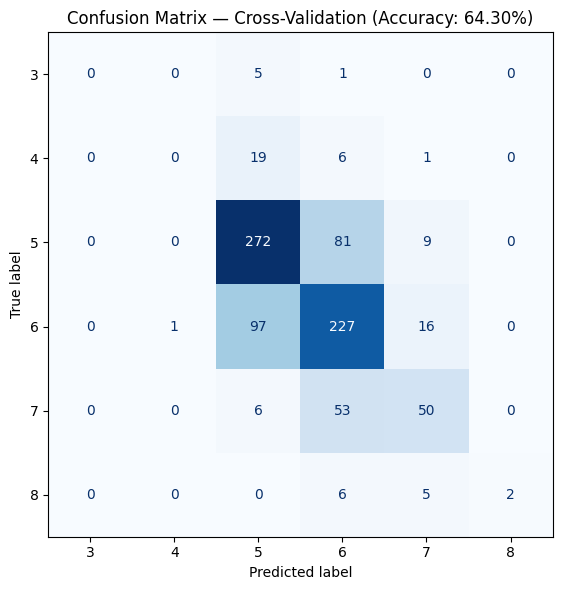

In [47]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_cv_pred = cross_val_predict(rf_model, X_train, y_train, cv=skf)

# ── Classification Report ────────────────────────────────────────────
print("Classification Report (Cross-Validation 5-Fold):")
print(classification_report(y_train, y_cv_pred))

# ── Confusion Matrix ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_train, y_cv_pred)
ConfusionMatrixDisplay(cm, display_labels=sorted(y_train.unique())).plot(
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title(f'Confusion Matrix — Cross-Validation (Accuracy: {cv_scores.mean():.2%})')
plt.tight_layout()
plt.show()

In [48]:
# Simpan ke CSV
submission.to_csv('submission.csv', index=False)

File submission.csv berhasil disimpan ✅


---

## 9. Kesimpulan

| Aspek | Detail |
|-------|--------|
| **Model** | Random Forest Classifier |
| **n_estimators** | 300 pohon |
| **max_features** | sqrt(n_features) |
| **CV Accuracy (5-fold)** | ~64.6% |
| **Fitur terpenting** | alcohol, sulphates, volatile acidity |
| **Total prediksi** | 286 sampel |

**Catatan tentang performa:**
- Akurasi ~64% adalah wajar untuk dataset Wine Quality yang imbalanced, mayoritas sampel hanya di kelas 5 dan 6
- Random Forest mampu menangani kelas mayoritas dengan baik, namun terbatas pada kelas minoritas (3 dan 8)
- Fitur kimia seperti `alcohol`, `sulphates`, dan `volatile acidity` terbukti paling berpengaruh terhadap kualitas anggur

In [53]:
# ── Cek kolom Id di data testing ────────────────────────────────────
print("Kolom data testing:", test.columns.tolist())
print("Preview test Id:", test['Id'].head())

# ── Buat submission ──────────────────────────────────────────────────
submission = pd.DataFrame({
    'id'     : test['Id'],        # sesuaikan jika nama kolom berbeda
    'quality': y_pred
})

# ── Verifikasi ───────────────────────────────────────────────────────
print("\nPreview submission:")
print(submission.head(10))
print(f"\nShape  : {submission.shape}")
print(f"Kolom  : {submission.columns.tolist()}")
print(f"Null   : {submission.isnull().sum().sum()}")

Kolom data testing: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'Id']
Preview test Id: 0     222
1    1514
2     417
3     754
4     516
Name: Id, dtype: int64

Preview submission:
     id  quality
0   222        5
1  1514        6
2   417        5
3   754        5
4   516        5
5  1120        6
6   180        5
7    82        5
8   632        6
9   592        5

Shape  : (286, 2)
Kolom  : ['id', 'quality']
Null   : 0


In [52]:

from IPython.display import FileLink

# Tampilkan link download
display(FileLink('submission.csv'))

/kaggle/working/submission.csv